In [1]:
import numpy as np
import matplotlib.pyplot as plt
import strawberryfields as sf
from strawberryfields.ops import*
from numpy.polynomial.hermite import hermgauss
from scipy.special import eval_hermite, factorial

In [2]:
def sf_protocol(eta, var, key_len):


    bob_bitstr = []
    alice_bitstr = []
    for i in range(key_len):
        prog = sf.Program(2)
        theta = np.arccos(np.sqrt(eta))
        with prog.context as q:

            # Input state on Alice's mode
            Vac | q[0]
            alpha_p = np.random.normal(0, np.sqrt(var))
            alpha_q = np.random.normal(0, np.sqrt(var))
            Xgate(alpha_q) | q[0]
            Zgate(alpha_p) | q[0]

            # Vacuum entering unused beam-splitter port
            Vac | q[1]
            # Beam splitter
            BSgate(theta, 0.0) | (q[0], q[1])

            x = np.random.randint(0, 2)
            if x==0:
                MeasureHomodyne(0) | q[0]
                alice_bitstr.append(alpha_q)
                
            else:
                MeasureHomodyne(np.pi/2) | q[0]
                alice_bitstr.append(alpha_p)


        eng = sf.Engine("gaussian")
        result = eng.run(prog)
        bob_bitstr.append(result.samples[0][0])
        eng.reset()

    return alice_bitstr, bob_bitstr



In [55]:
def G(x):
    if x==0:
        return 0
    return  (x + 1)*np.log2(x + 1) - x*np.log2(x)


def holevo_bound(lambda1, lambda2):
    return G((lambda1 - 1)/2) - G((lambda2 - 1)/2)

def lambda_RR(var_a, eta):
    lambda1 = 1+(1-eta)*var_a
    lambda2 = np.sqrt((1+(1-eta)*var_a)*(1+(1-eta)*var_a/(1+eta*var_a)))
    return lambda1, lambda2


def lambda_DR(var_a, eta):
    lambda1 = 1+(1-eta)*var_a
    lambda2 = 1
    return lambda1, lambda2

var_a = 1
eta = 0.6
print(holevo_bound(*lambda_RR(var_a, eta)))
print(holevo_bound(*lambda_DR(var_a, eta)))


0.10452386460800678
0.7800269059780249


In [ ]:
eta = 0.1
keylen=1000
sigma_grid = np.linspace(0,100,101)
I_grid=[]
holevo_grid=[]
for sigma in sigma_grid:
    alice_bitstr, bob_bitstr = sf_protocol(eta, sigma**2, keylen)
    rho = np.corrcoef(alice_bitstr, bob_bitstr)[0, 1]
    I_AB = -0.5 * np.log2(1 - rho**2)
    I_grid.append(I_AB)
    holevo_grid.append(holevo_bound(*lambda_RR(sigma**2, eta)))
    
    

c:\Users\kmits\Desktop\github\Quantum-Communications-Internship-IRIDA-\.venv\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
c:\Users\kmits\Desktop\github\Quantum-Communications-Internship-IRIDA-\.venv\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide


In [59]:
def key_rate(recon_eff, I, x):
    return recon_eff*np.array(I)-np.array(x)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


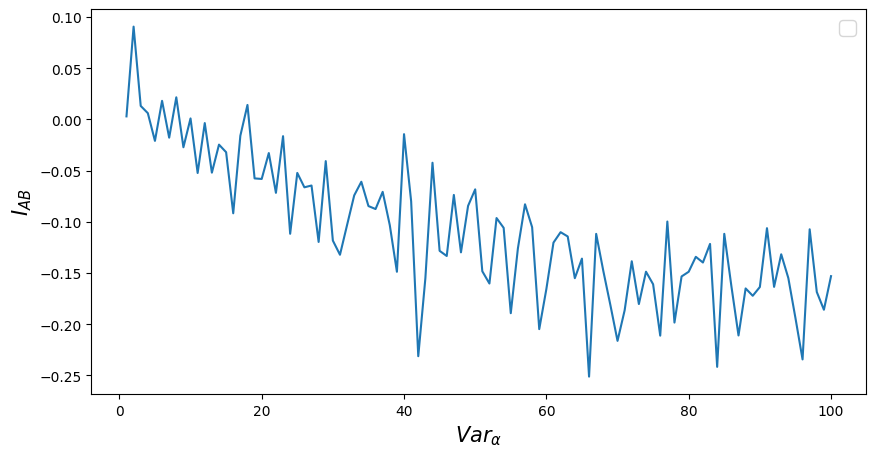

In [63]:
fig = plt.figure(figsize=(10,5), dpi=100)
#plt.scatter(sigma_grid, I_grid, s=15, color = 'magenta', label='MC data')
#plt.plot(sigma_grid, 1/2*np.log2(1+(sigma_grid**2*eta)/(1+eta*(1-1))), 'k', label='Theoretical curve')
plt.plot(sigma_grid, key_rate(0.95, I_grid, holevo_grid))
plt.xlabel(r'$Var_{{\alpha}}$', fontsize=15)
plt.ylabel(r'$I_{{AB}}$', fontsize=15)
plt.legend(fontsize=15)